## Research 05 — Combination Grid: How to Merge Horizons

### Why this notebook exists
Notebook 2 introduced one merge: **equal-weight average of 1/3/6/12 month signs**. That is a clean conviction dial, but it is only one design choice.

Here we ask: **among reasonable ways to combine horizons, what actually wins after costs?**

### Families we test
| Family | Idea |
|--------|------|
| Single horizon | Baseline: 1m, 3m, 6m, or 12m alone |
| Equal sign average | Average of signs on subsets (drop 1m, keep 6+12, …) |
| Weighted signs | Tilt weight toward slow or fast lookbacks |
| Raw then sign | Average trailing *returns*, then take the sign |
| Majority / threshold | Vote or trade only when conviction is high |

### How to read the results
1. **Sharpe_net** is the primary ranking metric (10 bps one-way turnover cost).
2. **MaxDD_net** matters if the goal is defense, not just return efficiency.
3. **Turnover** explains why fancy blends often lose — they trade more than plain 12m.
4. Charts show rankings, Sharpe-vs-turnover tradeoffs, and equity / drawdown paths.

Universe: SPY alone, then equal-weight SPY / BIL / IEF / TLT / GLD / BTC-USD.


In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

from helpers.data_utils import load_monthly_panel
from helpers.signal_utils import (
    trailing_return, sign_signal, multi_horizon_score,
    raw_return_score, majority_vote, threshold_score,
)
from helpers.backtest_utils import (
    position_from_signal, strategy_returns, perf_stats,
    turnover, apply_transaction_costs, equal_weight_portfolio,
)
from helpers.plot_utils import (
    plot_cumulative_comparison, plot_drawdown_comparison,
    plot_metric_bars, plot_scatter_metrics,
)

TICKERS = ["SPY", "BIL", "IEF", "TLT", "GLD", "BTC-USD"]
ALL_H = [1, 3, 6, 12]
COST_BPS = 10.0

px_m, r_m = load_monthly_panel(TICKERS)
trailing = {k: trailing_return(r_m, k) for k in ALL_H}
signals = {k: sign_signal(trailing[k]) for k in ALL_H}

display(Markdown(
    f"**Data loaded.** Monthly panel `{r_m.shape[0]}` months × `{r_m.shape[1]}` assets. "
    f"Cost assumption: **{COST_BPS:.0f} bps** one-way per unit of turnover."
))


Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350
Loaded BIL from cache: data/daily/BIL_adj_close.csv | rows=4741
Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: data/daily/TLT_adj_close.csv | rows=5957
Loaded GLD from cache: data/daily/GLD_adj_close.csv | rows=5375
Loaded BTC-USD from cache: data/daily/BTC-USD_adj_close.csv | rows=4216


**Data loaded.** Monthly panel `400` months × `6` assets. Cost assumption: **10 bps** one-way per unit of turnover.

### 1. Build the signal library

Each named **spec** is a full signal panel (same columns as the return panel).
Positions are always **lagged by one month** — no lookahead.


In [2]:
def subset(d, keys):
    return {k: d[k] for k in keys}

SPECS = {}

for k in ALL_H:
    SPECS[f"single_{k}m"] = signals[k]

SUBSETS = {
    "sign_eq_1_3_6_12": [1, 3, 6, 12],
    "sign_eq_3_6_12": [3, 6, 12],
    "sign_eq_6_12": [6, 12],
    "sign_eq_3_12": [3, 12],
    "sign_eq_1_3_6": [1, 3, 6],
    "sign_eq_3_6": [3, 6],
}
for name, keys in SUBSETS.items():
    SPECS[name] = multi_horizon_score(subset(signals, keys))

WEIGHTS = {
    "sign_w_slow": {1: 0.10, 3: 0.20, 6: 0.30, 12: 0.40},
    "sign_w_slower": {1: 0.05, 3: 0.15, 6: 0.30, 12: 0.50},
    "sign_w_no1_tilt12": {3: 0.20, 6: 0.30, 12: 0.50},
    "sign_w_fast": {1: 0.40, 3: 0.30, 6: 0.20, 12: 0.10},
}
for name, w in WEIGHTS.items():
    SPECS[name] = multi_horizon_score(subset(signals, list(w.keys())), weights=w)

RAW_SUBSETS = {
    "raw_eq_1_3_6_12": [1, 3, 6, 12],
    "raw_eq_3_6_12": [3, 6, 12],
    "raw_eq_6_12": [6, 12],
    "raw_w_slow": {1: 0.10, 3: 0.20, 6: 0.30, 12: 0.40},
}
for name, spec in RAW_SUBSETS.items():
    if isinstance(spec, list):
        SPECS[name] = raw_return_score(subset(trailing, spec), as_sign=True)
    else:
        SPECS[name] = raw_return_score(
            subset(trailing, list(spec.keys())), weights=spec, as_sign=True
        )

SPECS["maj_1_3_6_12"] = majority_vote(subset(signals, [1, 3, 6, 12]))
SPECS["maj_3_6_12"] = majority_vote(subset(signals, [3, 6, 12]))
SPECS["maj_1_3_6_12_min3"] = majority_vote(subset(signals, [1, 3, 6, 12]), min_agree=3)
SPECS["maj_3_6_12_min2"] = majority_vote(subset(signals, [3, 6, 12]), min_agree=2)

base = multi_horizon_score(subset(signals, [1, 3, 6, 12]))
SPECS["sign_eq_thr_0.5"] = threshold_score(base, min_abs=0.5)
SPECS["sign_eq_thr_0.75"] = threshold_score(base, min_abs=0.75)
SPECS["sign_eq_3_6_12_thr_0.5"] = threshold_score(
    multi_horizon_score(subset(signals, [3, 6, 12])), min_abs=0.5
)

def family(name: str) -> str:
    if name.startswith("single_"):
        return "single"
    if name.startswith("sign_eq"):
        return "sign_equal"
    if name.startswith("sign_w"):
        return "sign_weighted"
    if name.startswith("raw_"):
        return "raw_then_sign"
    if name.startswith("maj_"):
        return "majority"
    return "other"

print(f"Registered {len(SPECS)} specs across families:",
      sorted({family(n) for n in SPECS}))


Registered 25 specs across families: ['majority', 'raw_then_sign', 'sign_equal', 'sign_weighted', 'single']


### 2. Backtest each spec

For a signal $s_t$: position $p_t = s_{t-1}$, gross return $p_t r_t$,
net return = gross − turnover × cost.

- **SPY block:** use the SPY column only.
- **EW block:** equal-weight average of asset-level net strategy returns.


In [3]:
def eval_signal(signal, r, cost_bps=COST_BPS):
    pos = position_from_signal(signal, lag=1)
    gross = strategy_returns(pos, r)
    net = apply_transaction_costs(gross, pos, cost_bps=cost_bps)
    if isinstance(net, pd.DataFrame):
        port_net = equal_weight_portfolio(net)
        port_gross = equal_weight_portfolio(gross)
        turn = float(turnover(pos).mean().mean())
        stats_net = perf_stats(port_net)
        stats_gross = perf_stats(port_gross)
    else:
        turn = float(turnover(pos).mean())
        stats_net = perf_stats(net)
        stats_gross = perf_stats(gross)
        port_net = net
    return {
        "Sharpe_gross": float(stats_gross["Sharpe"]),
        "Sharpe_net": float(stats_net["Sharpe"]),
        "CAGR_net": float(stats_net["CAGR"]),
        "MaxDD_net": float(stats_net["Max Drawdown"]),
        "Vol_net": float(stats_net["Ann. Vol"]),
        "Turnover": turn,
        "port_net": port_net,
    }

bh_spy = perf_stats(r_m["SPY"])
bh_ew = perf_stats(equal_weight_portfolio(r_m))
display(Markdown(
    f"**Buy-and-hold reference** — SPY Sharpe `{bh_spy['Sharpe']:.2f}`, "
    f"EW basket Sharpe `{bh_ew['Sharpe']:.2f}`."
))


**Buy-and-hold reference** — SPY Sharpe `0.75`, EW basket Sharpe `0.94`.

### 3. SPY results — tables and charts

**Reading tip:** the table is sorted by `Sharpe_net`. Anchor every comparison to `single_12m`.
If a blend has lower Sharpe *and* higher turnover, it is mostly paying for noise.


In [4]:
spy_rows, spy_ports = [], {}
for name, sig in SPECS.items():
    col = sig["SPY"] if isinstance(sig, pd.DataFrame) else sig
    out = eval_signal(col, r_m["SPY"])
    spy_ports[name] = out.pop("port_net")
    spy_rows.append({"spec": name, "family": family(name), **out})

spy_grid = (
    pd.DataFrame(spy_rows).set_index("spec").sort_values("Sharpe_net", ascending=False)
)
display(Markdown("#### Full SPY ranking (net of 10 bps)"))
display(spy_grid.round(4))
display(Markdown("#### Top 8 and bottom 4"))
display(pd.concat([spy_grid.head(8), spy_grid.tail(4)]).round(4))


#### Full SPY ranking (net of 10 bps)

,family,Sharpe_gross,Sharpe_net,CAGR_net,MaxDD_net,Vol_net,Turnover
spec,,,,,,,
single_12m,single,0.7104,0.7110,0.0992,-0.3671,0.1492,0.0829
sign_eq_6_12,sign_equal,0.6752,0.6694,0.0862,-0.4034,0.1383,0.1528
sign_w_slower,sign_weighted,0.6730,0.6621,0.0786,-0.3449,0.1267,0.2018
sign_w_no1_tilt12,sign_weighted,0.6631,0.6542,0.0795,-0.3435,0.1303,0.1839
sign_w_slow,sign_weighted,0.6472,0.6311,0.0711,-0.3247,0.1208,0.2492
raw_eq_1_3_6_12,raw_then_sign,0.6336,0.6239,0.0854,-0.3877,0.1499,0.2073
raw_eq_6_12,raw_then_sign,0.6091,0.6051,0.0825,-0.3973,0.1501,0.1347
sign_eq_3_6_12,sign_equal,0.6058,0.5925,0.0698,-0.3264,0.1280,0.2280
raw_w_slow,raw_then_sign,0.5921,0.5872,0.0796,-0.3973,0.1502,0.1451


#### Top 8 and bottom 4

,family,Sharpe_gross,Sharpe_net,CAGR_net,MaxDD_net,Vol_net,Turnover
spec,,,,,,,
single_12m,single,0.7104,0.7110,0.0992,-0.3671,0.1492,0.0829
sign_eq_6_12,sign_equal,0.6752,0.6694,0.0862,-0.4034,0.1383,0.1528
sign_w_slower,sign_weighted,0.6730,0.6621,0.0786,-0.3449,0.1267,0.2018
sign_w_no1_tilt12,sign_weighted,0.6631,0.6542,0.0795,-0.3435,0.1303,0.1839
sign_w_slow,sign_weighted,0.6472,0.6311,0.0711,-0.3247,0.1208,0.2492
raw_eq_1_3_6_12,raw_then_sign,0.6336,0.6239,0.0854,-0.3877,0.1499,0.2073
raw_eq_6_12,raw_then_sign,0.6091,0.6051,0.0825,-0.3973,0.1501,0.1347
sign_eq_3_6_12,sign_equal,0.6058,0.5925,0.0698,-0.3264,0.1280,0.2280
sign_w_fast,sign_weighted,0.4475,0.4043,0.0396,-0.2726,0.1117,0.4855


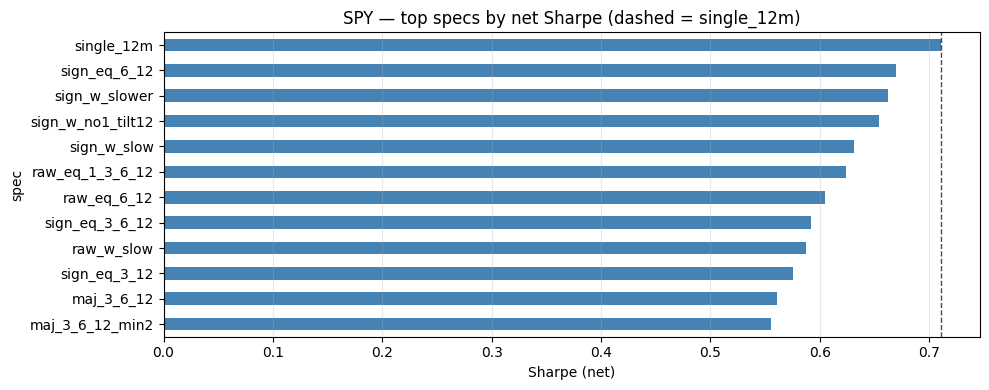

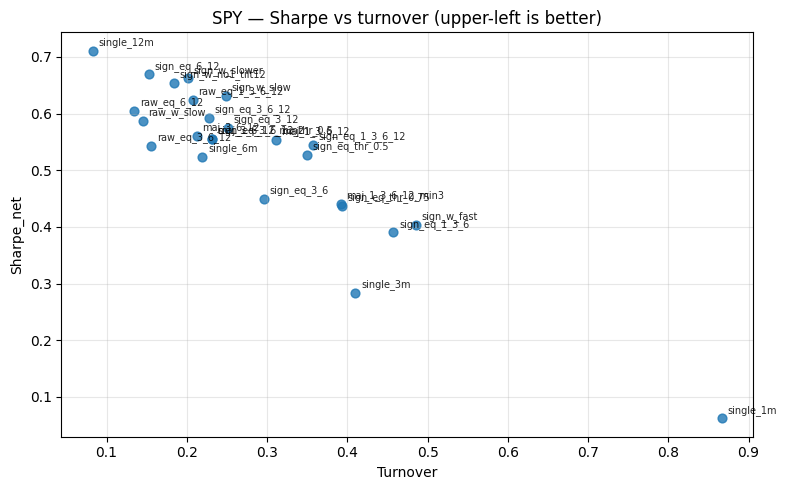

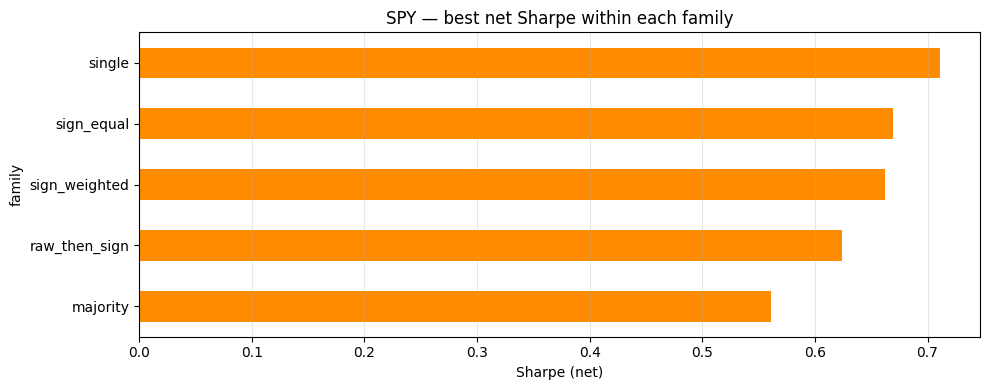

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'SPY — best net Sharpe within each family'}, xlabel='Sharpe (net)', ylabel='family'>)

In [5]:
plot_metric_bars(
    spy_grid["Sharpe_net"].head(12),
    title="SPY — top specs by net Sharpe (dashed = single_12m)",
    ylabel="Sharpe (net)",
    hline=float(spy_grid.loc["single_12m", "Sharpe_net"]),
)
plot_scatter_metrics(
    spy_grid.reset_index(),
    x="Turnover",
    y="Sharpe_net",
    label_col="spec",
    title="SPY — Sharpe vs turnover (upper-left is better)",
)
fam_best = spy_grid.groupby("family")["Sharpe_net"].max().sort_values()
plot_metric_bars(
    fam_best,
    title="SPY — best net Sharpe within each family",
    ylabel="Sharpe (net)",
    color="darkorange",
)


### 4. Equal-weight multi-asset results

Diversification is where TSMOM usually looks better. Same specs; equal-weight across assets each month.


In [6]:
ew_rows, ew_ports = [], {}
for name, sig in SPECS.items():
    out = eval_signal(sig, r_m)
    ew_ports[name] = out.pop("port_net")
    ew_rows.append({"spec": name, "family": family(name), **out})

ew_grid = (
    pd.DataFrame(ew_rows).set_index("spec").sort_values("Sharpe_net", ascending=False)
)
display(Markdown("#### Full EW ranking (net of 10 bps)"))
display(ew_grid.round(4))
display(Markdown("#### Top 8"))
display(ew_grid.head(8).round(4))


#### Full EW ranking (net of 10 bps)

,family,Sharpe_gross,Sharpe_net,CAGR_net,MaxDD_net,Vol_net,Turnover
spec,,,,,,,
single_12m,single,0.8828,0.8997,0.1071,-0.2276,0.1218,0.1655
sign_eq_6_12,sign_equal,0.8507,0.8620,0.0956,-0.2135,0.1137,0.2162
sign_w_slower,sign_weighted,0.8471,0.8508,0.0879,-0.1622,0.1058,0.2614
sign_w_no1_tilt12,sign_weighted,0.8267,0.8341,0.0881,-0.1564,0.1086,0.2447
raw_eq_1_3_6_12,raw_then_sign,0.8137,0.8203,0.0977,-0.2726,0.1233,0.2612
sign_w_slow,sign_weighted,0.8243,0.8197,0.0812,-0.1385,0.1018,0.3024
raw_w_slow,raw_then_sign,0.8047,0.8137,0.0970,-0.2343,0.1235,0.2121
raw_eq_6_12,raw_then_sign,0.7844,0.7934,0.0944,-0.2312,0.1237,0.1988
raw_eq_3_6_12,raw_then_sign,0.7618,0.7699,0.0917,-0.2726,0.1243,0.2086


#### Top 8

,family,Sharpe_gross,Sharpe_net,CAGR_net,MaxDD_net,Vol_net,Turnover
spec,,,,,,,
single_12m,single,0.8828,0.8997,0.1071,-0.2276,0.1218,0.1655
sign_eq_6_12,sign_equal,0.8507,0.8620,0.0956,-0.2135,0.1137,0.2162
sign_w_slower,sign_weighted,0.8471,0.8508,0.0879,-0.1622,0.1058,0.2614
sign_w_no1_tilt12,sign_weighted,0.8267,0.8341,0.0881,-0.1564,0.1086,0.2447
raw_eq_1_3_6_12,raw_then_sign,0.8137,0.8203,0.0977,-0.2726,0.1233,0.2612
sign_w_slow,sign_weighted,0.8243,0.8197,0.0812,-0.1385,0.1018,0.3024
raw_w_slow,raw_then_sign,0.8047,0.8137,0.0970,-0.2343,0.1235,0.2121
raw_eq_6_12,raw_then_sign,0.7844,0.7934,0.0944,-0.2312,0.1237,0.1988


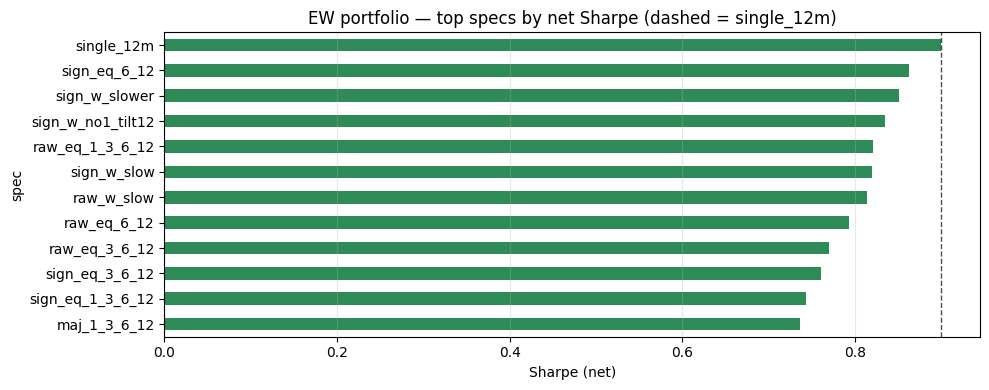

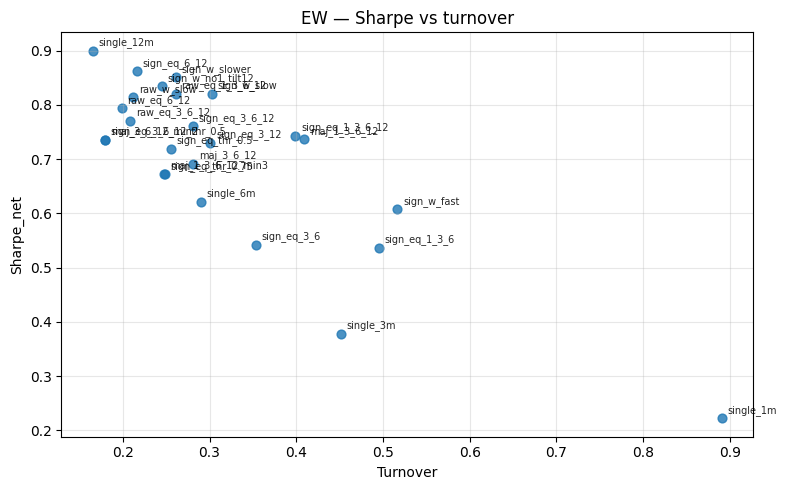

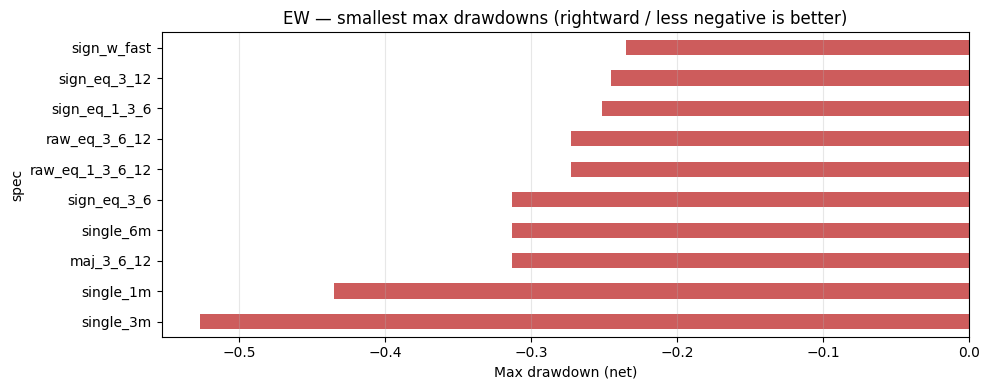

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'EW — smallest max drawdowns (rightward / less negative is better)'}, xlabel='Max drawdown (net)', ylabel='spec'>)

In [7]:
plot_metric_bars(
    ew_grid["Sharpe_net"].head(12),
    title="EW portfolio — top specs by net Sharpe (dashed = single_12m)",
    ylabel="Sharpe (net)",
    hline=float(ew_grid.loc["single_12m", "Sharpe_net"]),
    color="seagreen",
)
plot_scatter_metrics(
    ew_grid.reset_index(),
    x="Turnover",
    y="Sharpe_net",
    label_col="spec",
    title="EW — Sharpe vs turnover",
)
plot_metric_bars(
    ew_grid["MaxDD_net"].nsmallest(10),
    title="EW — smallest max drawdowns (rightward / less negative is better)",
    ylabel="Max drawdown (net)",
    color="indianred",
)


### 5. Head-to-head story charts

A shortlist for narrative — not every grid row needs an equity curve.


#### SPY shortlist

,family,Sharpe_gross,Sharpe_net,CAGR_net,MaxDD_net,Vol_net,Turnover
spec,,,,,,,
single_12m,single,0.7104,0.7110,0.0992,-0.3671,0.1492,0.0829
sign_eq_1_3_6_12,sign_equal,0.5746,0.5452,0.0560,-0.2817,0.1115,0.3575
sign_eq_3_6_12,sign_equal,0.6058,0.5925,0.0698,-0.3264,0.1280,0.2280
sign_eq_6_12,sign_equal,0.6752,0.6694,0.0862,-0.4034,0.1383,0.1528
sign_w_slow,sign_weighted,0.6472,0.6311,0.0711,-0.3247,0.1208,0.2492
sign_w_slower,sign_weighted,0.6730,0.6621,0.0786,-0.3449,0.1267,0.2018
raw_eq_3_6_12,raw_then_sign,0.5494,0.5433,0.0727,-0.4477,0.1506,0.1554
maj_3_6_12,majority,0.5711,0.5606,0.0754,-0.3973,0.1504,0.2124
sign_eq_thr_0.75,sign_equal,0.4833,0.4369,0.0396,-0.2474,0.1007,0.3932


#### EW shortlist

,family,Sharpe_gross,Sharpe_net,CAGR_net,MaxDD_net,Vol_net,Turnover
spec,,,,,,,
single_12m,single,0.8828,0.8997,0.1071,-0.2276,0.1218,0.1655
sign_eq_1_3_6_12,sign_equal,0.7696,0.7428,0.0684,-0.1764,0.0954,0.3991
sign_eq_3_6_12,sign_equal,0.7589,0.7601,0.0788,-0.2092,0.1076,0.2807
sign_eq_6_12,sign_equal,0.8507,0.8620,0.0956,-0.2135,0.1137,0.2162
sign_w_slow,sign_weighted,0.8243,0.8197,0.0812,-0.1385,0.1018,0.3024
sign_w_slower,sign_weighted,0.8471,0.8508,0.0879,-0.1622,0.1058,0.2614
raw_eq_3_6_12,raw_then_sign,0.7618,0.7699,0.0917,-0.2726,0.1243,0.2086
maj_3_6_12,majority,0.6899,0.6915,0.0816,-0.3131,0.1250,0.2815
sign_eq_thr_0.75,sign_equal,0.7238,0.6721,0.0555,-0.2034,0.0859,0.2479


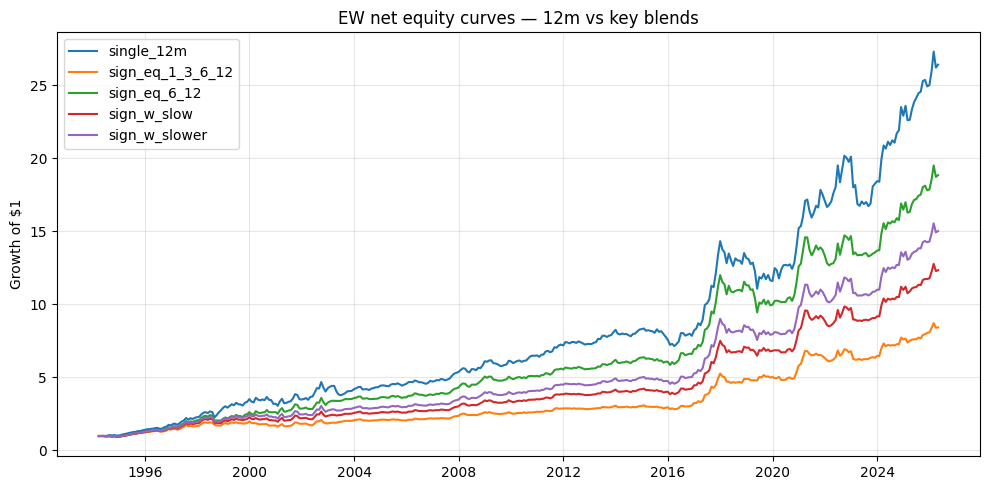

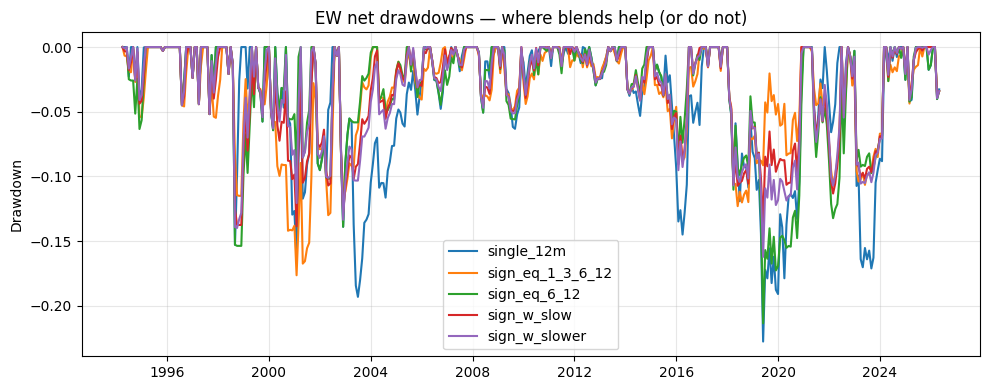

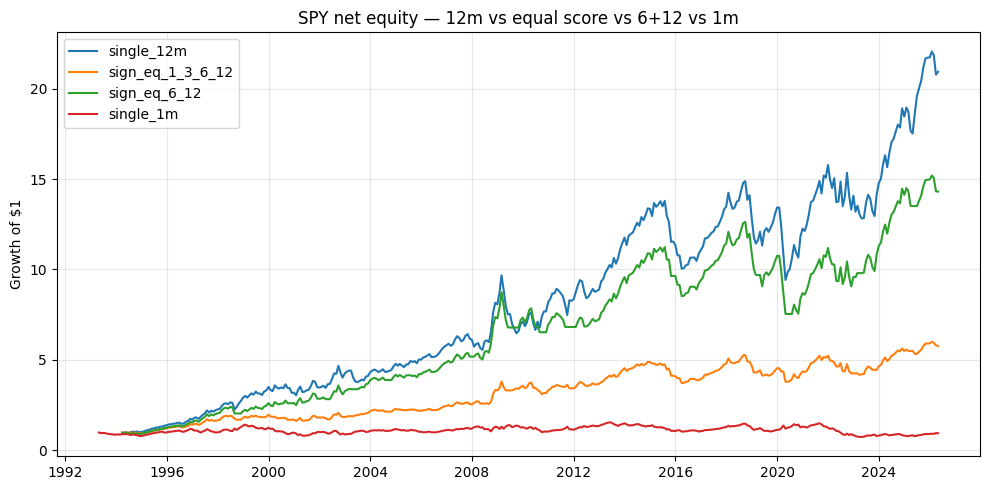

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'SPY net equity — 12m vs equal score vs 6+12 vs 1m'}, ylabel='Growth of $1'>)

In [8]:
KEYS = [
    "single_12m",
    "sign_eq_1_3_6_12",
    "sign_eq_3_6_12",
    "sign_eq_6_12",
    "sign_w_slow",
    "sign_w_slower",
    "raw_eq_3_6_12",
    "maj_3_6_12",
    "sign_eq_thr_0.75",
    "single_1m",
]

display(Markdown("#### SPY shortlist"))
display(spy_grid.loc[[k for k in KEYS if k in spy_grid.index]].round(4))
display(Markdown("#### EW shortlist"))
display(ew_grid.loc[[k for k in KEYS if k in ew_grid.index]].round(4))

top_ew = list(ew_grid.head(3).index)
story = list(dict.fromkeys(
    ["single_12m", "sign_eq_1_3_6_12", "sign_eq_6_12", "sign_w_slow"] + top_ew
))
plot_cumulative_comparison(
    {n: ew_ports[n] for n in story},
    title="EW net equity curves — 12m vs key blends",
)
plot_drawdown_comparison(
    {n: ew_ports[n] for n in story},
    title="EW net drawdowns — where blends help (or do not)",
)
plot_cumulative_comparison(
    {n: spy_ports[n] for n in ["single_12m", "sign_eq_1_3_6_12", "sign_eq_6_12", "single_1m"]},
    title="SPY net equity — 12m vs equal score vs 6+12 vs 1m",
)


### 6. Written findings

Prose below is generated from the grids so the narrative stays tied to the numbers.


In [9]:
def findings(grid, label):
    best = grid.index[0]
    base, eq, drop1 = "single_12m", "sign_eq_1_3_6_12", "sign_eq_3_6_12"
    lines = [
        f"**{label}**",
        f"- Best net Sharpe: `{best}` ({grid.loc[best, 'Sharpe_net']:.3f}).",
        f"- Plain 12m: `{grid.loc[base, 'Sharpe_net']:.3f}` (turnover {grid.loc[base, 'Turnover']:.3f}).",
        f"- Full equal score 1/3/6/12: `{grid.loc[eq, 'Sharpe_net']:.3f}` (turnover {grid.loc[eq, 'Turnover']:.3f}).",
        f"- Drop 1-month (3/6/12): `{grid.loc[drop1, 'Sharpe_net']:.3f}`.",
    ]
    if "sign_eq_6_12" in grid.index:
        lines.append(
            f"- Best simple subset 6+12: `{grid.loc['sign_eq_6_12', 'Sharpe_net']:.3f}`."
        )
    short = [k for k in KEYS if k in grid.index]
    def_row = grid.loc[short]["MaxDD_net"].idxmax()
    lines.append(
        f"- Among the story shortlist, smallest |max DD|: `{def_row}` "
        f"({grid.loc[def_row, 'MaxDD_net']:.1%})."
    )
    return "\n".join(lines)

display(Markdown(findings(spy_grid, "SPY")))
display(Markdown(findings(ew_grid, "Equal-weight portfolio")))
display(Markdown('''### Bottom line
1. **12-month sign still wins Sharpe** after a real merge bake-off.
2. **Dropping the 1-month leg helps** the equal-weight score; **6+12** is the closest challenger.
3. **Slow weight tilts** recover toward 12m; fast tilts and hard thresholds mostly add cost or flatten exposure.
4. Use blends when the goal is a **drawdown dial**, not when the goal is beating 12m Sharpe.
'''))


**SPY**
- Best net Sharpe: `single_12m` (0.711).
- Plain 12m: `0.711` (turnover 0.083).
- Full equal score 1/3/6/12: `0.545` (turnover 0.358).
- Drop 1-month (3/6/12): `0.592`.
- Best simple subset 6+12: `0.669`.
- Among the story shortlist, smallest |max DD|: `sign_eq_thr_0.75` (-24.7%).

**Equal-weight portfolio**
- Best net Sharpe: `single_12m` (0.900).
- Plain 12m: `0.900` (turnover 0.165).
- Full equal score 1/3/6/12: `0.743` (turnover 0.399).
- Drop 1-month (3/6/12): `0.760`.
- Best simple subset 6+12: `0.862`.
- Among the story shortlist, smallest |max DD|: `sign_w_slow` (-13.9%).

### Bottom line
1. **12-month sign still wins Sharpe** after a real merge bake-off.
2. **Dropping the 1-month leg helps** the equal-weight score; **6+12** is the closest challenger.
3. **Slow weight tilts** recover toward 12m; fast tilts and hard thresholds mostly add cost or flatten exposure.
4. Use blends when the goal is a **drawdown dial**, not when the goal is beating 12m Sharpe.


In [10]:
from pathlib import Path
import json

out_dir = Path("research")
spy_grid.to_csv(out_dir / "combo_grid_spy.csv")
ew_grid.to_csv(out_dir / "combo_grid_ew.csv")
summary = {
    "spy_best": spy_grid.index[0],
    "spy_best_sharpe_net": float(spy_grid.iloc[0]["Sharpe_net"]),
    "spy_12m_sharpe_net": float(spy_grid.loc["single_12m", "Sharpe_net"]),
    "spy_eq_full_sharpe_net": float(spy_grid.loc["sign_eq_1_3_6_12", "Sharpe_net"]),
    "ew_best": ew_grid.index[0],
    "ew_best_sharpe_net": float(ew_grid.iloc[0]["Sharpe_net"]),
    "ew_12m_sharpe_net": float(ew_grid.loc["single_12m", "Sharpe_net"]),
    "ew_eq_full_sharpe_net": float(ew_grid.loc["sign_eq_1_3_6_12", "Sharpe_net"]),
}
(out_dir / "combo_grid_summary.json").write_text(json.dumps(summary, indent=2))
display(Markdown("Saved `combo_grid_spy.csv`, `combo_grid_ew.csv`, `combo_grid_summary.json`."))
display(summary)


Saved `combo_grid_spy.csv`, `combo_grid_ew.csv`, `combo_grid_summary.json`.

{'spy_best': 'single_12m',
 'spy_best_sharpe_net': 0.7110243445626303,
 'spy_12m_sharpe_net': 0.7110243445626303,
 'spy_eq_full_sharpe_net': 0.5452090641490397,
 'ew_best': 'single_12m',
 'ew_best_sharpe_net': 0.8996663845240507,
 'ew_12m_sharpe_net': 0.8996663845240507,
 'ew_eq_full_sharpe_net': 0.7427626856192429}